Importing Required Libraries

In this step, we import the necessary Python libraries required for data analysis, visualization, model building, and performance evaluation.

• Pandas and NumPy are used for data manipulation.
• Matplotlib and Seaborn are used for data visualization.
• Scikit-learn provides tools for machine learning, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Loading the Dataset

The Boston Housing dataset is loaded from an online source. This dataset contains information about housing characteristics and prices. It will be used to build a Linear Regression model for house price prediction.


In [2]:
url = "/content/BostonHousing.csv"

df = pd.read_csv(url)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Understanding the Dataset

Before building a machine learning model, it is important to understand the dataset structure, including the number of rows, columns, data types, and basic information.

In [3]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (506, 14)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Observation:

The dataset contains multiple numerical features related to housing characteristics. These features will be used to predict house prices.

Checking for Missing Values

Missing values can negatively affect model performance. Therefore, the dataset is checked to ensure all required information is available.

In [6]:
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


Observation:

No missing values were found in the dataset.

Correlation Analysis

A correlation heatmap is used to understand relationships between features and identify which variables have stronger influence on house prices.

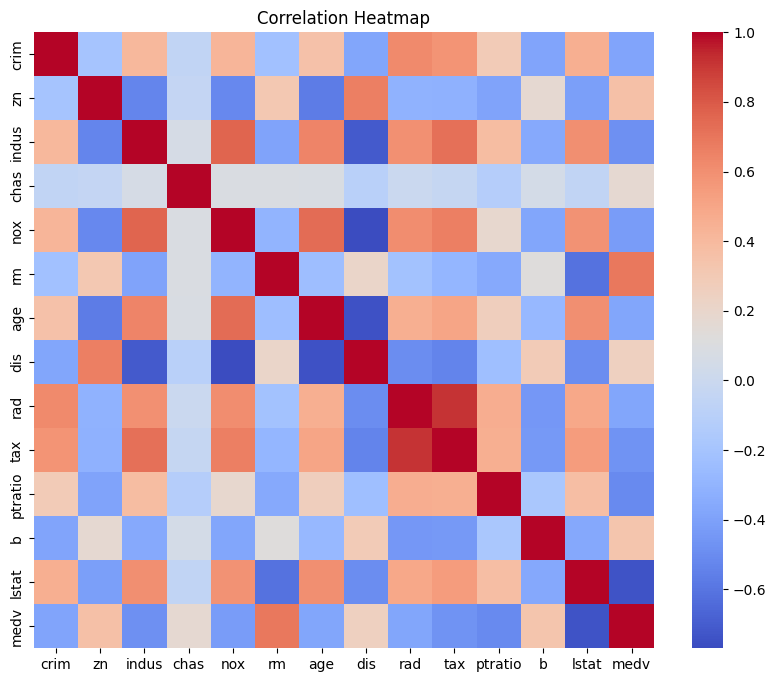

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=False,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Observation:

Several features show positive and negative correlations with house prices, indicating their influence on prediction.

Selecting Features and Target Variable

The target variable is the house price (MEDV). All remaining columns are used as input features for training the Linear Regression model.

In [15]:
print(df.columns)

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')


In [11]:
X = df.drop('medv', axis=1)

y = df['medv']

Splitting Dataset

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate performance.

In [16]:
X = df.drop('medv', axis=1)
y = df['medv']

Training the Model

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values. The model is trained using the training dataset.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Training the Model

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values. The model is trained using the training dataset.

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Making Predictions

The trained model is used to predict house prices for the testing dataset.

In [19]:
y_pred = model.predict(X_test)

Model Evaluation

Model performance is evaluated using Mean Squared Error (MSE) and R² Score.

• MSE measures prediction error.
• R² Score indicates how well the model explains variation in house prices.

In [20]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 24.291119474973478


In [21]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.6687594935356326


Observation:

The obtained R² Score indicates the effectiveness of the Linear Regression model in predicting house prices.

Visualizing Predictions

A scatter plot is created to compare actual house prices with predicted house prices. A strong alignment indicates good model performance.

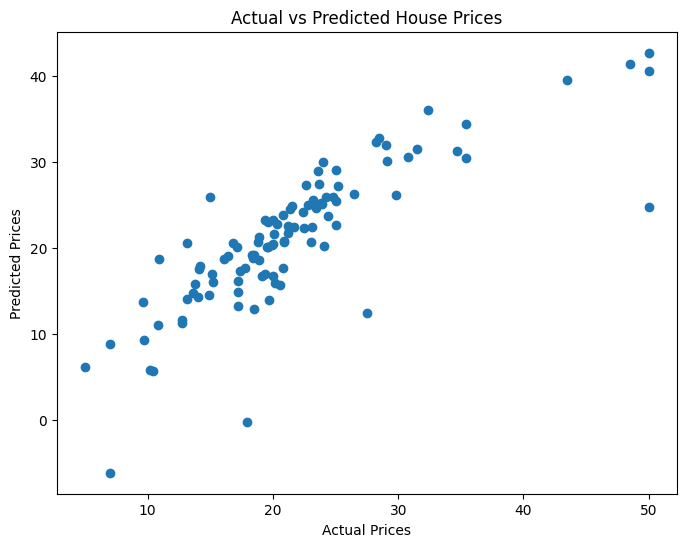

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

Observation:

The predicted values closely follow the actual values, indicating reasonable prediction accuracy.

Analyzing Feature Importance

The coefficients of the Linear Regression model help identify which features have the strongest influence on house prices.

In [23]:
coeff_df = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)

coeff_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Coefficient
rm,4.438835
chas,2.784438
rad,0.262430
indus,0.040381
zn,0.030110
b,0.012351
age,-0.006296
tax,-0.010647
crim,-0.113056
lstat,-0.508571


Observation:

Features with larger coefficient values have greater impact on house price prediction.

Conclusion

1. The housing dataset was successfully analyzed.
2. A Linear Regression model was trained and tested.
3. Model performance was evaluated using MSE and R² Score.
4. Actual and predicted prices were visualized.
5. The model demonstrated effective predictive capability for house price estimation.
6. Linear Regression can be used as a baseline model for real-world price prediction problems.